In [4]:
!pip -q install mediapipe opencv-python matplotlib



Поза человека найдена.


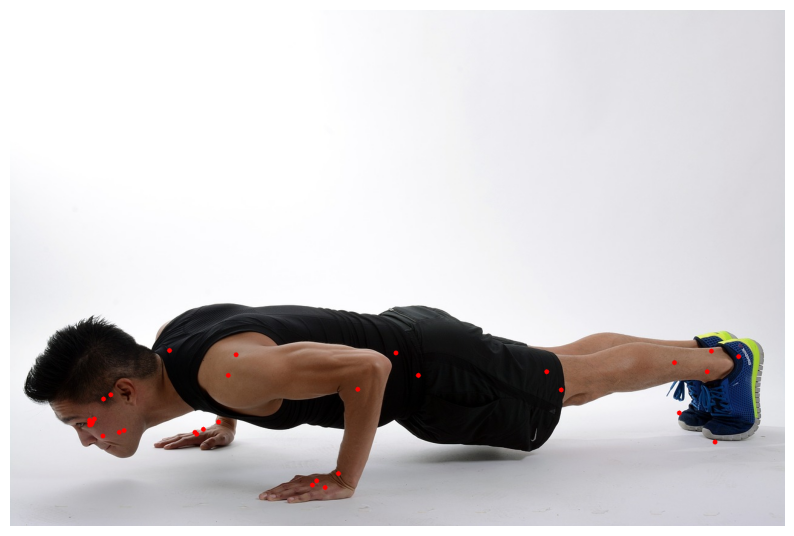

In [6]:


import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import urllib.request
import os

# Скачиваем модель для PoseLandmarker
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
model_path = "pose_landmarker_lite.task"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

# Загружаем изображение
img = cv2.imread("111.jpg")
if img is None:
    raise FileNotFoundError("Файл 111.jpg не найден.")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

# Настройка PoseLandmarker
BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1
)

# Обработка изображения
with PoseLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_image)

# Рисуем точки
annotated = rgb.copy()

if result.pose_landmarks:
    for pose_landmarks in result.pose_landmarks:
        for lm in pose_landmarks:
            h, w, _ = annotated.shape
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 4, (255, 0, 0), -1)
    print("Поза человека найдена.")
else:
    print("Поза человека не найдена.")

plt.figure(figsize=(10, 10))
plt.imshow(annotated)
plt.axis("off")
plt.show()